In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import statsmodels.api as sm

df = pd.read_csv('Student_Performance.csv',sep=',')

In [29]:
map_bin = {'Yes':1,"No":0}
df = df.replace(map_bin)
display(df.head(5))

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [22]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int64  
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


None

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,0.494800,6.530600,4.583300,55.224800
std,2.589309,17.343152,0.499998,1.695863,2.867348,19.212558
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


In [23]:
display(df.corr())

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.003873,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.008369,0.005944,0.007888,0.915189
Extracurricular Activities,0.003873,0.008369,1.000000,-0.023284,0.013103,0.024525
Sleep Hours,0.001245,0.005944,-0.023284,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.013103,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.024525,0.048106,0.043268,1.000000


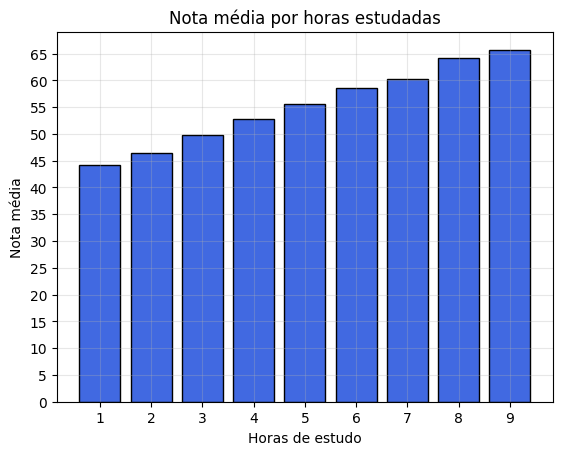

In [24]:
df_nota_estudo = df[['Hours Studied','Performance Index']].copy()
df_nota_estudo = df_nota_estudo.groupby('Hours Studied',as_index=False).mean()

plt.figure()
plt.grid(alpha=0.3)
plt.xticks(np.arange(1,10,1))
plt.yticks(np.arange(0,110,5))
plt.title('Nota média por horas estudadas')
plt.bar(x=df_nota_estudo['Hours Studied'],height=df_nota_estudo['Performance Index'],edgecolor='black',color='royalblue')
plt.xlabel('Horas de estudo')
plt.ylabel('Nota média')
plt.show()

[]

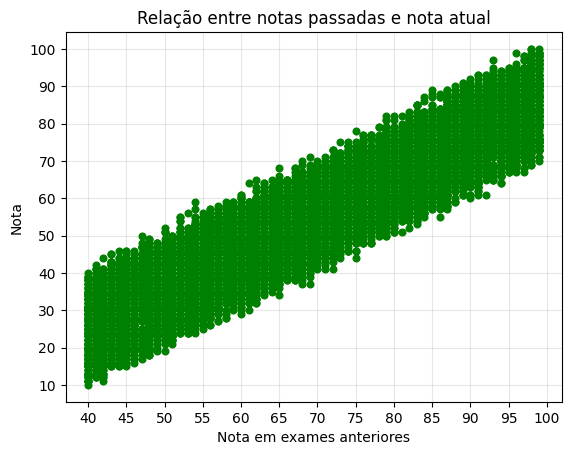

In [25]:
plt.figure()
plt.grid(alpha=0.3)
plt.xticks(np.arange(0,110,5))
plt.yticks(np.arange(0,110,10))
plt.plot(df['Previous Scores'],df['Performance Index'],'o',markersize=4.8,color='green')
plt.xlabel('Nota em exames anteriores')
plt.ylabel('Nota')
plt.title('Relação entre notas passadas e nota atual')
plt.plot()

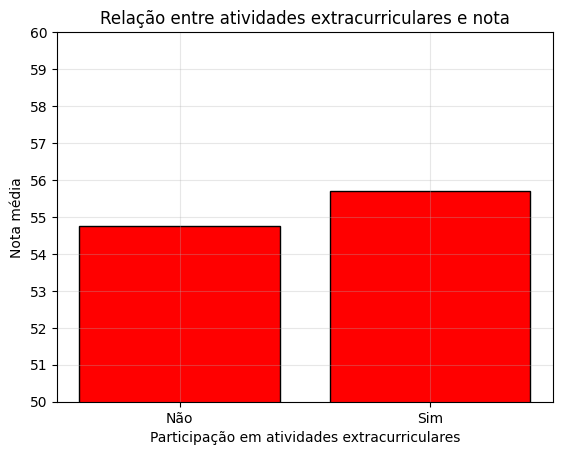

In [26]:
df_nota_atividade = df[['Extracurricular Activities','Performance Index']].copy()
df_nota_atividade = df_nota_atividade.groupby('Extracurricular Activities',as_index=False).mean()

plt.figure()
plt.grid(alpha=0.3)
plt.xticks([0,1],['Não','Sim'])
plt.yticks(np.arange(0,110,1))
plt.title('Relação entre atividades extracurriculares e nota')
plt.bar(x=df_nota_atividade['Extracurricular Activities'],height=df_nota_atividade['Performance Index'],edgecolor='black',color='red')
plt.xlabel('Participação em atividades extracurriculares')
plt.ylabel('Nota média')
plt.ylim(50,60)
plt.show()

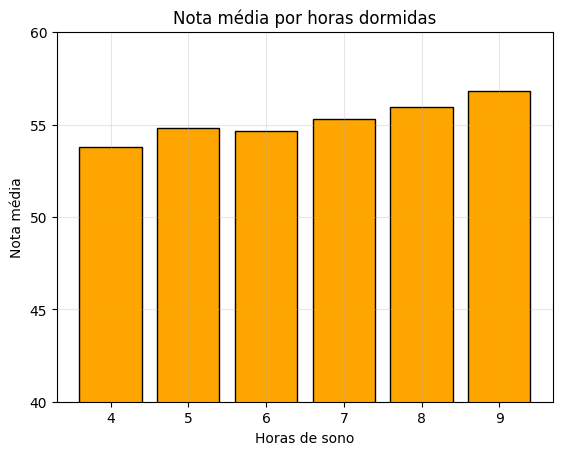

In [27]:
df_nota_sono = df[['Sleep Hours','Performance Index']].copy()
df_nota_sono = df_nota_sono.groupby('Sleep Hours',as_index=False).mean()


plt.figure()
plt.grid(alpha=0.3)
plt.xticks(np.arange(1,10,1))
plt.yticks(np.arange(0,110,5))
plt.title('Nota média por horas dormidas')
plt.bar(x=df_nota_sono['Sleep Hours'],height=df_nota_sono['Performance Index'],edgecolor='black',color='orange')
plt.xlabel('Horas de sono')
plt.ylabel('Nota média')
plt.ylim(40,60)
plt.show()


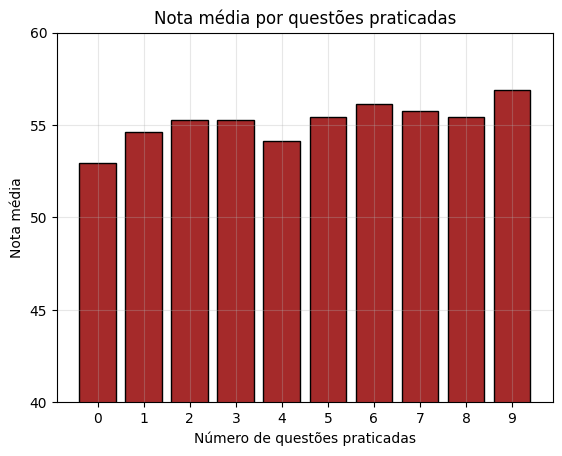

In [28]:
df_nota_exercicio = df[['Sample Question Papers Practiced','Performance Index']].copy()
df_nota_exercicio = df_nota_exercicio.groupby('Sample Question Papers Practiced',as_index=False).mean()

plt.figure()
plt.grid(alpha=0.3)
plt.xticks(np.arange(0,10,1))
plt.yticks(np.arange(0,110,5))
plt.title('Nota média por questões praticadas')
plt.bar(x=df_nota_exercicio['Sample Question Papers Practiced'],height=df_nota_exercicio['Performance Index'],edgecolor='black',color='brown')
plt.xlabel('Número de questões praticadas')
plt.ylabel('Nota média')
plt.ylim(40,60)
plt.show()